# E-Commerce Sales & Customer Analysis

This project analyzes more than 500,000 online retail transactions using Python, Pandas, and Matplotlib.

The goal is to evaluate sales performance, customer behavior, product performance, geographic trends, and returns in order to identify actionable business insights.

## 1. Data Loading

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Inspection

Before cleaning the dataset, I reviewed its size, columns, missing values, duplicates, data types, cancellations, and potentially invalid transactions.

In [15]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [16]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows:
5268


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [18]:
print("Negative quantities:", (df["Quantity"] < 0).sum())

print(
    "Zero or negative prices:",
    (df["UnitPrice"] <= 0).sum()
)

print(
    "Rows belonging to cancelled invoices:",
    df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Negative quantities: 10624
Zero or negative prices: 2517
Rows belonging to cancelled invoices: 9288


## 3. Data Cleaning

The raw dataset contains duplicate records, cancelled transactions, returns, missing customer identifiers, and transactions with invalid quantities or prices.

Separate datasets were created for completed sales, customer-level analysis, and returns/cancellations so that useful information was preserved instead of simply deleting all problematic transactions.

In [19]:
# Preserve returns/cancellations for separate analysis
returns_df = df[
    (df["Quantity"] < 0) |
    (df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

# Create clean sales dataset
sales_df = df.copy()

# Remove duplicate rows
sales_df = sales_df.drop_duplicates()

# Keep only completed positive sales
sales_df = sales_df[
    (sales_df["Quantity"] > 0) &
    (sales_df["UnitPrice"] > 0) &
    (~sales_df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

# Remove rows without product descriptions
sales_df = sales_df.dropna(subset=["Description"])

print("Original rows:", len(df))
print("Clean sales rows:", len(sales_df))
print("Return/cancellation rows:", len(returns_df))


Original rows: 541909
Clean sales rows: 524878
Return/cancellation rows: 10624


In [20]:
customer_df = sales_df.dropna(
    subset=["CustomerID"]
).copy()

customer_df["CustomerID"] = (
    customer_df["CustomerID"].astype(int)
)

print("Sales rows:", len(sales_df))
print(
    "Rows available for customer analysis:",
    len(customer_df)
)
print(
    "Unique customers:",
    customer_df["CustomerID"].nunique()
)

Sales rows: 524878
Rows available for customer analysis: 392692
Unique customers: 4338


## 4. Sales Performance KPIs

Core performance indicators were calculated to summarize the overall scale and financial performance of the e-commerce operation.

In [21]:
# Calculate transaction revenue
sales_df["Revenue"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

customer_df["Revenue"] = (
    customer_df["Quantity"] * customer_df["UnitPrice"]
)

# Calculate KPIs
total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
total_units = sales_df["Quantity"].sum()
unique_products = sales_df["StockCode"].nunique()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Units Sold: {total_units:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Units Sold: 5,572,420
Unique Products: 3,922
Average Order Value: £533.17


In [22]:
print("Sales Period:")
print("Start:", sales_df["InvoiceDate"].min())
print("End:", sales_df["InvoiceDate"].max())

Sales Period:
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00


## 5. Monthly Revenue Trend

Monthly revenue was analyzed to identify seasonality, periods of high demand, and the strongest sales months.

December 2011 contains only a partial month of transactions, so it should not be directly compared with complete months.

In [23]:
sales_df["YearMonth"] = (
    sales_df["InvoiceDate"]
    .dt.to_period("M")
)

monthly_revenue = (
    sales_df
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["YearMonth"]
    .astype(str)
)

monthly_revenue

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


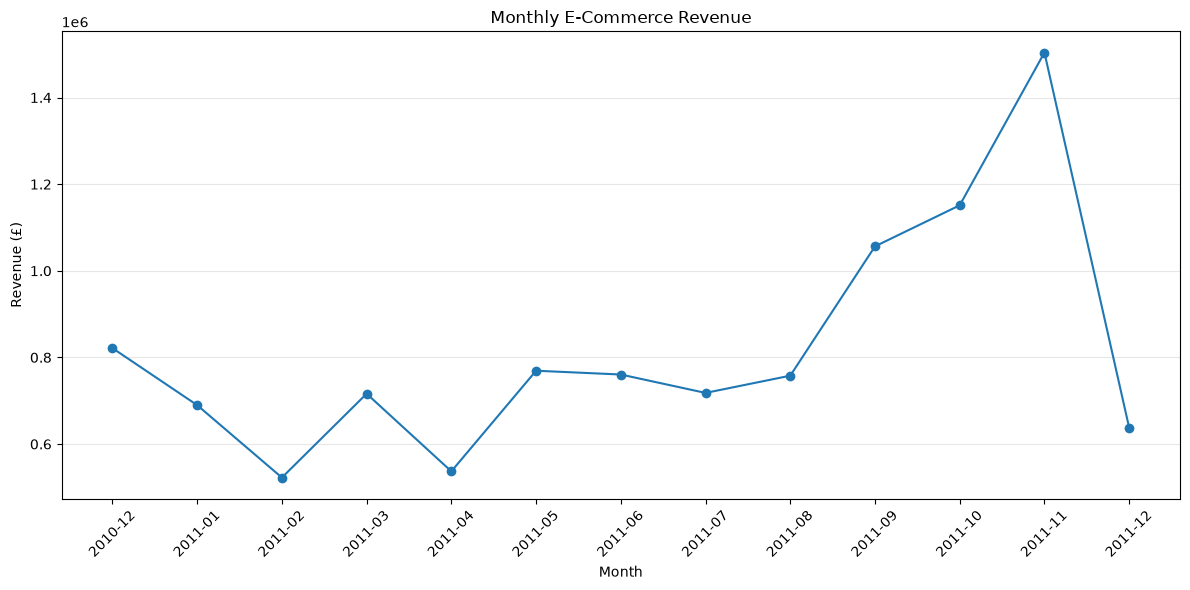

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly E-Commerce Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
peak_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

print(
    "Highest Revenue Month:",
    peak_month["YearMonth"]
)

print(
    f"Revenue: £{peak_month['Revenue']:,.2f}"
)

Highest Revenue Month: 2011-11
Revenue: £1,503,866.78


## 6. Product Performance

Product-level revenue was analyzed to identify which products contributed the most to total sales.

In [26]:
top_products = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


In [27]:
# Remove non-product/service items from product analysis
non_products = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual"
]

product_sales = sales_df[
    ~sales_df["Description"].isin(non_products)
].copy()

top_products = (
    product_sales
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,174156.54
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
3,PARTY BUNTING,99445.23
4,JUMBO BAG RED RETROSPOT,94159.81
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
6,RABBIT NIGHT LIGHT,66870.03
7,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
8,ASSORTED COLOUR BIRD ORNAMENT,58927.62
9,CHILLI LIGHTS,54096.36


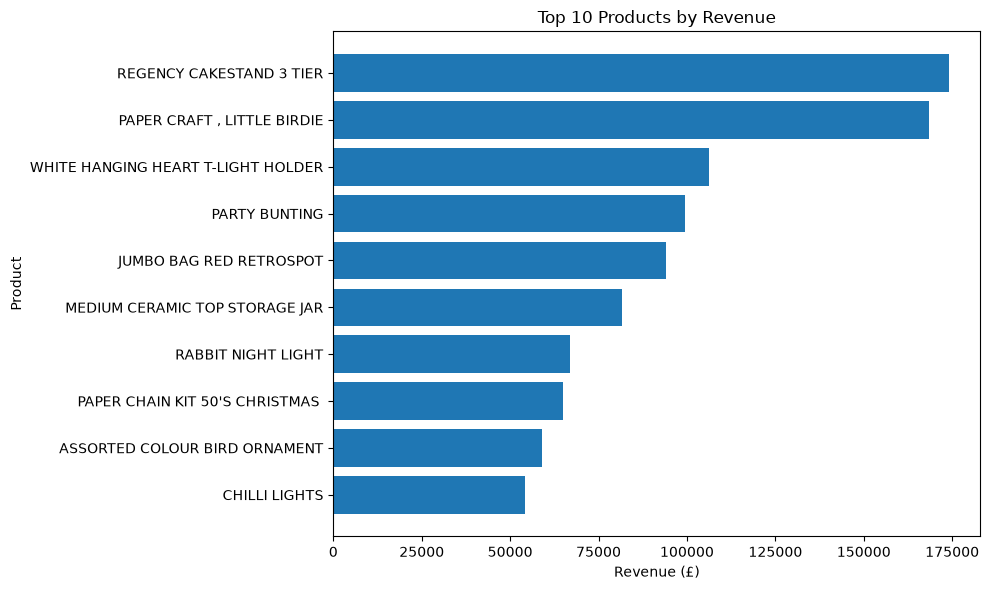

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
top_products_units = (
    product_sales
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_units

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


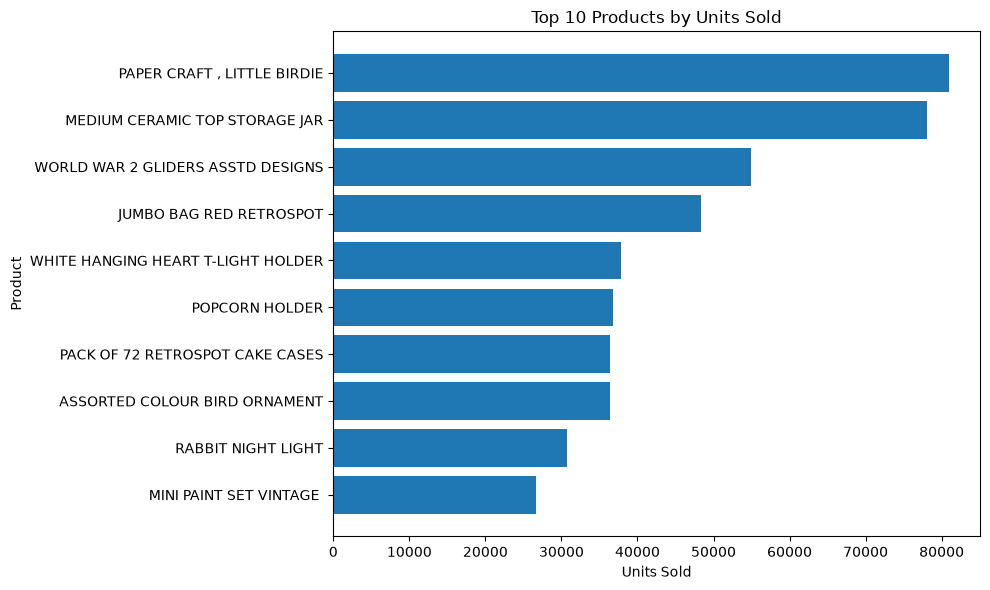

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_units["Description"],
    top_products_units["Quantity"]
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Geographic Sales Analysis

Revenue was analyzed by country to understand where sales are concentrated and to identify the strongest international markets.

In [31]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(10)

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


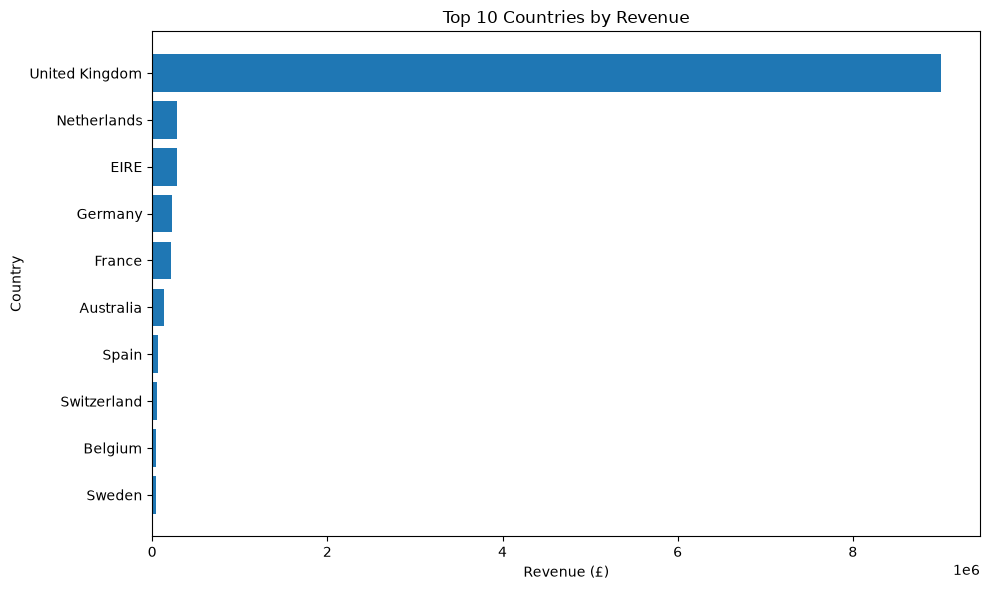

In [32]:
top_countries = country_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [33]:
international_sales = (
    sales_df[
        sales_df["Country"] != "United Kingdom"
    ]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

international_sales

,Country,Revenue
0,Netherlands,285446.34
1,EIRE,283140.52
2,Germany,228678.40
3,France,209625.37
4,Australia,138453.81
5,Spain,61558.56
6,Switzerland,57067.60
7,Belgium,41196.34
8,Sweden,38367.83
9,Japan,37416.37


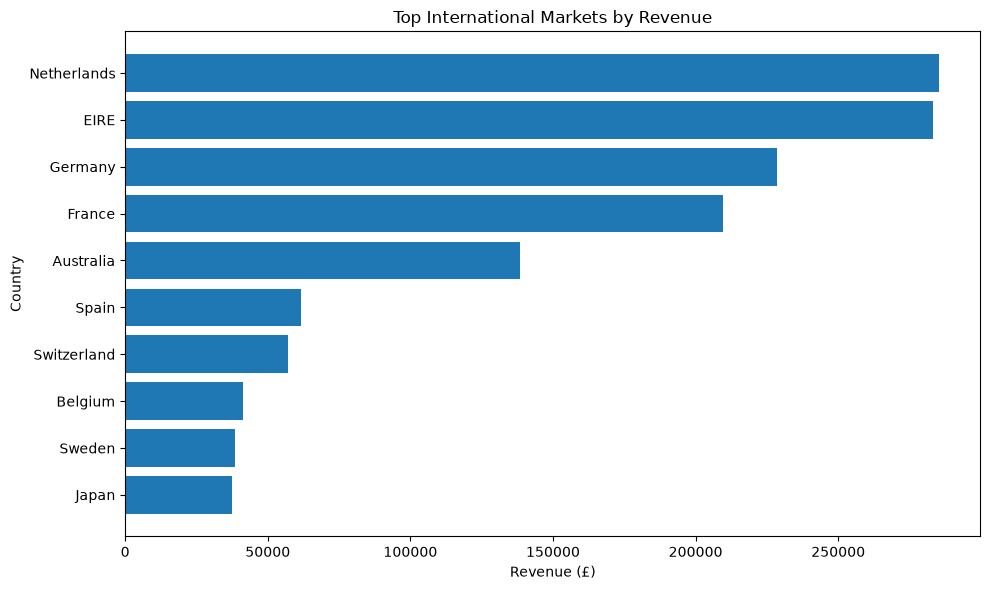

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    international_sales["Country"],
    international_sales["Revenue"]
)

plt.title("Top International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Customer Analysis

Customer purchasing behavior was analyzed to identify the highest-value customers and understand how revenue is distributed across the customer base.

In [35]:
top_customers = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(10)
    .reset_index()
)

top_customers

,CustomerID,Revenue,Orders
0,14646,280206.02,73
1,18102,259657.30,60
2,17450,194390.79,46
3,16446,168472.50,2
4,14911,143711.17,201
5,12415,124914.53,21
6,14156,117210.08,55
7,17511,91062.38,31
8,16029,80850.84,63
9,12346,77183.60,1


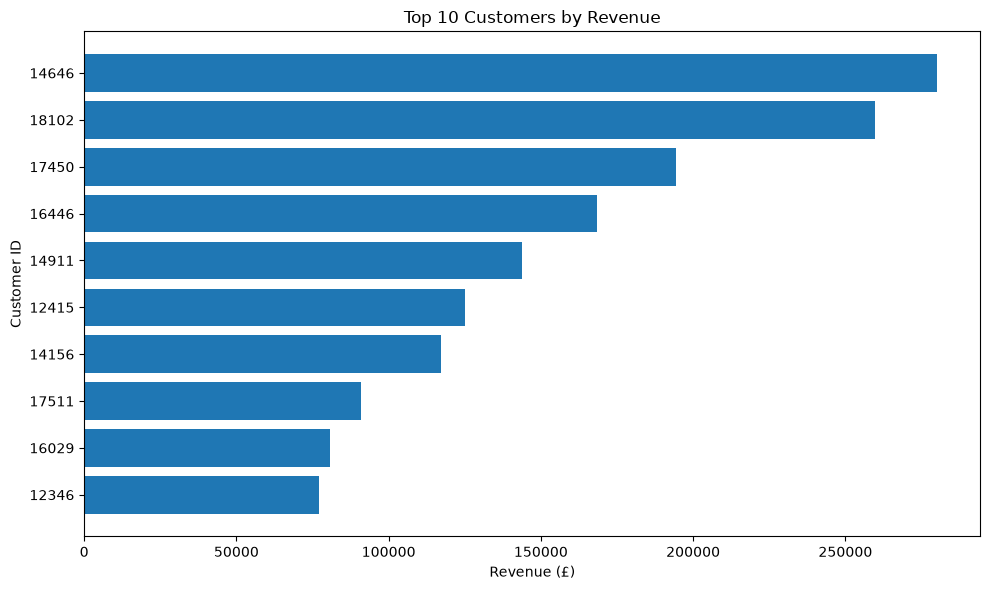

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["CustomerID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 9. RFM Customer Segmentation

RFM analysis was used to segment customers based on:

- Recency: how recently the customer purchased
- Frequency: how many orders the customer placed
- Monetary Value: how much revenue the customer generated

In [37]:
snapshot_date = (
    customer_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (snapshot_date - x.max()).days
        ),
        Frequency=(
            "InvoiceNo",
            "nunique"
        ),
        Monetary=(
            "Revenue",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [38]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total
0,12346,326,1,77183.60,1,1,4,6
1,12347,2,7,4310.00,4,4,4,12
2,12348,75,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,3,1,4,8
4,12350,310,1,334.40,1,1,2,4


In [39]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total
0,12346,326,1,77183.60,1,1,4,6
1,12347,2,7,4310.00,4,4,4,12
2,12348,75,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,3,1,4,8
4,12350,310,1,334.40,1,1,2,4


In [40]:
def customer_segment(score):
    if score >= 11:
        return "Champions"
    elif score >= 9:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "Needs Attention"
    else:
        return "At Risk"


rfm["Segment"] = (
    rfm["RFM_Total"]
    .apply(customer_segment)
)

segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    "Segment",
    "Customers"
]

segment_summary

,Segment,Customers
0,Needs Attention,999
1,Champions,867
2,Potential Loyalists,859
3,At Risk,808
4,Loyal Customers,805


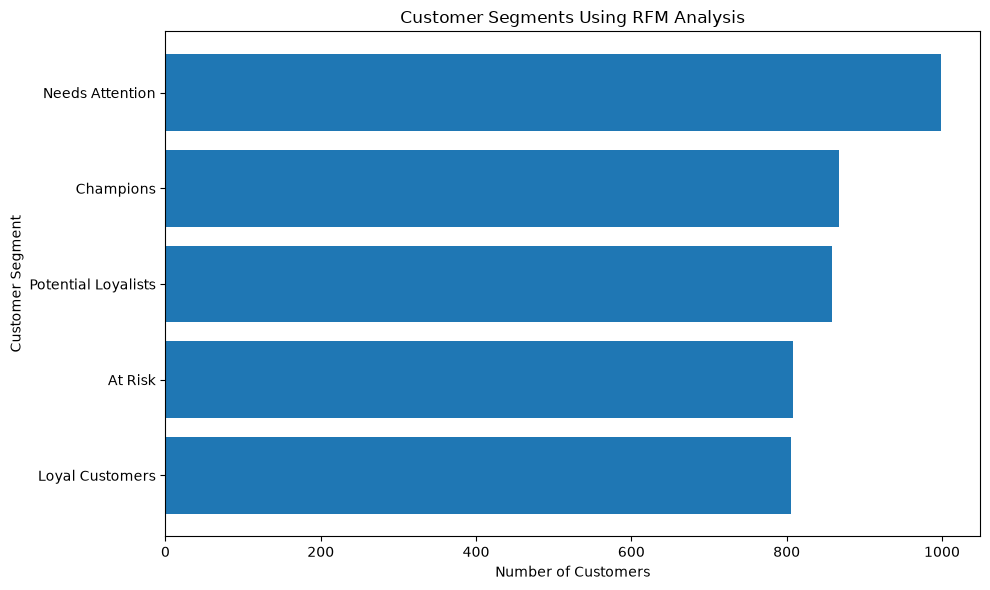

In [41]:
plt.figure(figsize=(10, 6))

plt.barh(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title("Customer Segments Using RFM Analysis")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Returns and Cancellations

Returns and cancelled transactions were analyzed separately from completed sales so they would not distort revenue calculations.

In [42]:
returns_clean = (
    returns_df
    .drop_duplicates()
    .copy()
)

cancelled_orders = (
    returns_clean[
        returns_clean["InvoiceNo"]
        .astype(str)
        .str.startswith("C")
    ]["InvoiceNo"]
    .nunique()
)

returned_units = abs(
    returns_clean.loc[
        returns_clean["Quantity"] < 0,
        "Quantity"
    ].sum()
)

print("Unique Cancelled Orders:", f"{cancelled_orders:,}")
print("Returned Units:", f"{returned_units:,}")

Unique Cancelled Orders: 3,836
Returned Units: 482,517


In [43]:
return_value_df = returns_clean[
    (returns_clean["Quantity"] < 0) &
    (returns_clean["UnitPrice"] > 0)
].copy()

return_value_df["ReturnValue"] = (
    return_value_df["Quantity"].abs()
    * return_value_df["UnitPrice"]
)

estimated_return_value = (
    return_value_df["ReturnValue"].sum()
)

print(
    f"Estimated Return Value: "
    f"£{estimated_return_value:,.2f}"
)

Estimated Return Value: £893,979.73


## 11. Key Findings

- The business generated approximately **£10.64 million in completed sales revenue** from **19,960 orders**.
- **November 2011** was the strongest revenue month, generating approximately **£1.50 million**.
- Revenue increased substantially from September through November, indicating strong seasonal demand toward the end of the year.
- **REGENCY CAKESTAND 3 TIER** was the highest-revenue merchandise product, generating approximately **£174,157**.
- **PAPER CRAFT, LITTLE BIRDIE** was the highest-volume product, with approximately **80,995 units sold**.
- The **United Kingdom** accounted for the majority of revenue, while the Netherlands, EIRE, Germany, and France were the strongest international markets.
- Customer **14646** was the highest-value customer, generating approximately **£280,206** in revenue.
- RFM analysis identified **867 Champions**, **805 Loyal Customers**, and **999 customers needing attention**.
- Returns and cancellations represented a significant operational concern, with **3,836 cancelled orders** and an estimated return value of approximately **£893,980**.

## 12. Business Recommendations

- Increase inventory and marketing support for top-performing products, especially high-revenue and high-volume items.
- Prepare for stronger demand during the fall and holiday season by increasing stock levels before September through November.
- Continue expanding into strong international markets such as the Netherlands, EIRE, Germany, and France.
- Develop retention campaigns for **Champions** and **Loyal Customers** to protect high-value customer relationships.
- Create re-engagement campaigns for customers classified as **Needs Attention** and **At Risk**.
- Investigate the causes of cancelled orders and returns to reduce revenue loss and improve customer satisfaction.
- Monitor high-value customers closely and consider personalized offers, account management, or loyalty incentives.